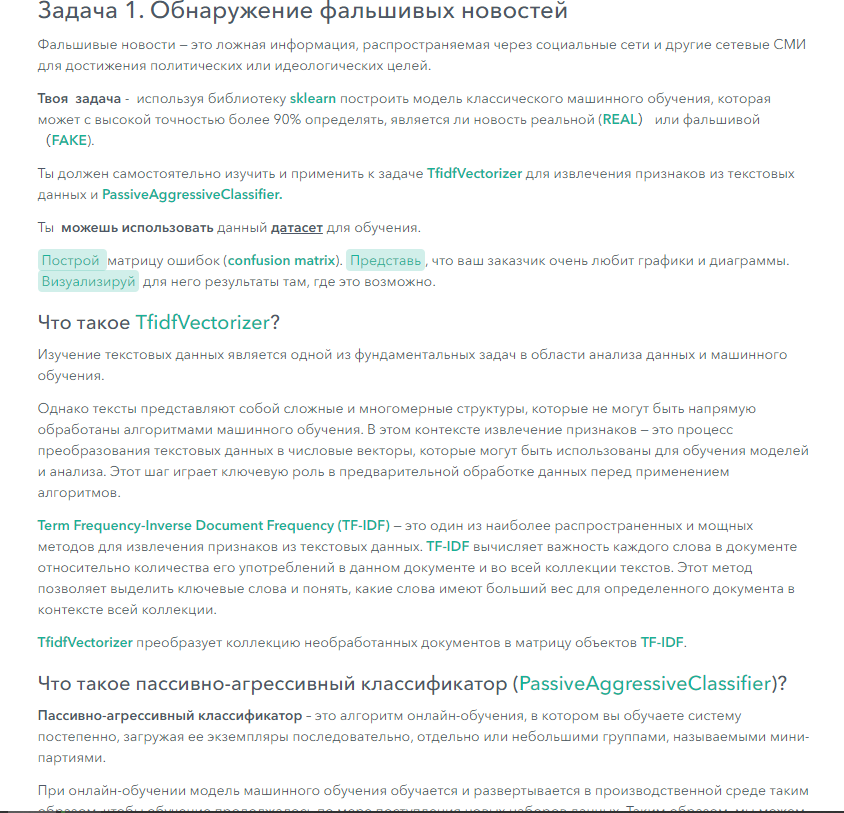

Первым делом, посмотрим на наши данные, затем примением TF-IDF к нашей задаче.

In [ ]:
import numpy as np
import pandas as pd
import itertools
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
df=pd.read_csv('/fake_news.csv')

In [ ]:
df.shape

(6335, 4)

In [ ]:
df.head()

,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6335 entries, 0 to 6334
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  6335 non-null   int64 
 1   title       6335 non-null   object
 2   text        6335 non-null   object
 3   label       6335 non-null   object
dtypes: int64(1), object(3)
memory usage: 198.1+ KB


In [ ]:
df.label.value_counts()


,count
label,
REAL,3171
FAKE,3164


In [ ]:
i=df.label.value_counts()
fig = go.Figure(data=[go.Bar(
            x=['Real','Fake'], y=i,
            text=i,
            textposition='auto',
        )])

fig.show()

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(df['text'], df.label, test_size=0.2, random_state=7)

In [ ]:
tfidf_vectorizer=TfidfVectorizer(stop_words='english', max_df=0.7)
tfidf_train=tfidf_vectorizer.fit_transform(X_train)
tfidf_test=tfidf_vectorizer.transform(X_test)
pac=PassiveAggressiveClassifier(max_iter=50)
pac.fit(tfidf_train,y_train)

PassiveAggressiveClassifier(max_iter=50)

In [ ]:
PassiveAggressiveClassifier(max_iter=50)
y_pred=pac.predict(tfidf_test)
score=accuracy_score(y_test,y_pred)
print(f'Accuracy: {round(score*100,2)}%')
confusion_matrix(y_test,y_pred, labels=['FAKE','REAL'])
print('\n clasification report:\n',classification_report(y_test,y_pred))

Accuracy: 92.82%

 clasification report:
               precision    recall  f1-score   support

        FAKE       0.93      0.92      0.93       638
        REAL       0.92      0.93      0.93       629

    accuracy                           0.93      1267
   macro avg       0.93      0.93      0.93      1267
weighted avg       0.93      0.93      0.93      1267



In [ ]:
# Попросил сгенерировать фейковые новости
sample_text = [
    "Aliens Land in New York City, Demand to Meet the Mayor",
    "Scientists Discover Fountain of Youth in Antarctica",
    "Local Man Claims to Have Invented Time Travel, Travels to 2050",
    "World's First Invisible Car Hits the Market Next Month",
    "Mysterious Giant Footprints Found in Central Park, Experts Stumped",
    "New Study Finds Chocolate Makes You Live Longer, Says It’s a Health Food",
    "Governments Secretly Planning to Switch to a 30-Hour Work Week",
    "Study Reveals Cats Are Actually Aliens Sent to Observe Humans",
    "New App Claims to Predict the Future with 99% Accuracy",
    "Dinosaurs Spotted on Remote Island, Tourists Encouraged to Visit"
]# Преобразуем текст с помощью TfidfVectorizer
sample_tfidf = tfidf_vectorizer.transform(sample_text)

# Выполним предсказание
prediction = pac.predict(sample_tfidf)

# Выводим результат
print(f'The prediction for the sample text is: {prediction[0]}')


The prediction for the sample text is: FAKE


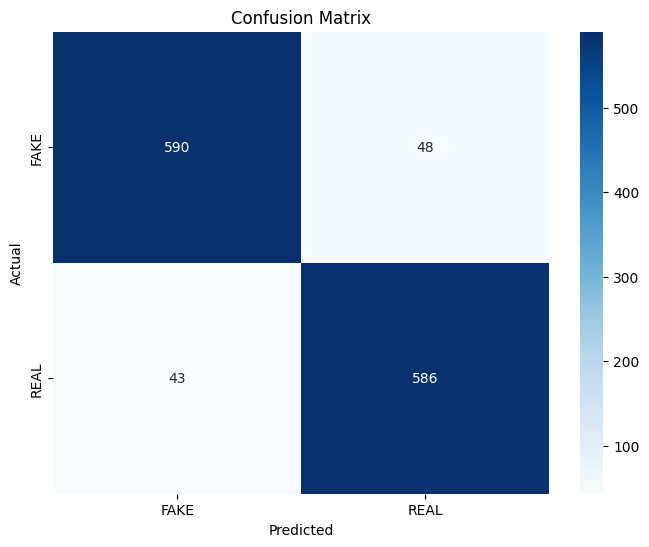

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred, labels=['FAKE', 'REAL'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['FAKE', 'REAL'], yticklabels=['FAKE', 'REAL'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()


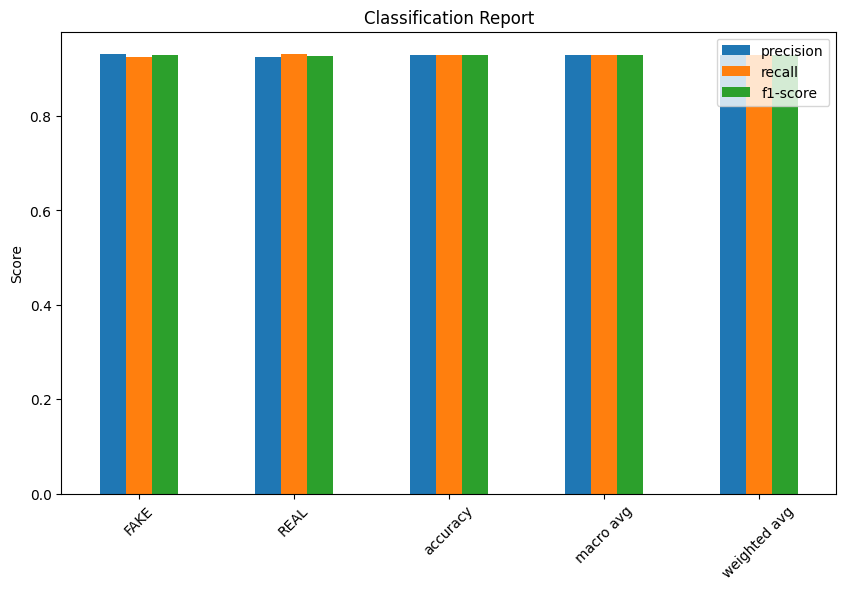

In [ ]:
# Получаем отчёт о классификации
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Визуализируем precision, recall и f1-score
report_df[['precision', 'recall', 'f1-score']].plot(kind='bar', figsize=(10, 6))
plt.title('Classification Report')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.show()


In [ ]:
# Выводим предсказания
for text, pred in zip(sample_text, prediction):
    print(f'Text: "{text}" \nPredicted label: {pred}\n')


Text: "Aliens Land in New York City, Demand to Meet the Mayor" 
Predicted label: FAKE

Text: "Scientists Discover Fountain of Youth in Antarctica" 
Predicted label: FAKE

Text: "Local Man Claims to Have Invented Time Travel, Travels to 2050" 
Predicted label: FAKE

Text: "World's First Invisible Car Hits the Market Next Month" 
Predicted label: FAKE

Text: "Mysterious Giant Footprints Found in Central Park, Experts Stumped" 
Predicted label: FAKE

Text: "New Study Finds Chocolate Makes You Live Longer, Says It’s a Health Food" 
Predicted label: FAKE

Text: "Governments Secretly Planning to Switch to a 30-Hour Work Week" 
Predicted label: FAKE

Text: "Study Reveals Cats Are Actually Aliens Sent to Observe Humans" 
Predicted label: FAKE

Text: "New App Claims to Predict the Future with 99% Accuracy" 
Predicted label: FAKE

Text: "Dinosaurs Spotted on Remote Island, Tourists Encouraged to Visit" 
Predicted label: FAKE



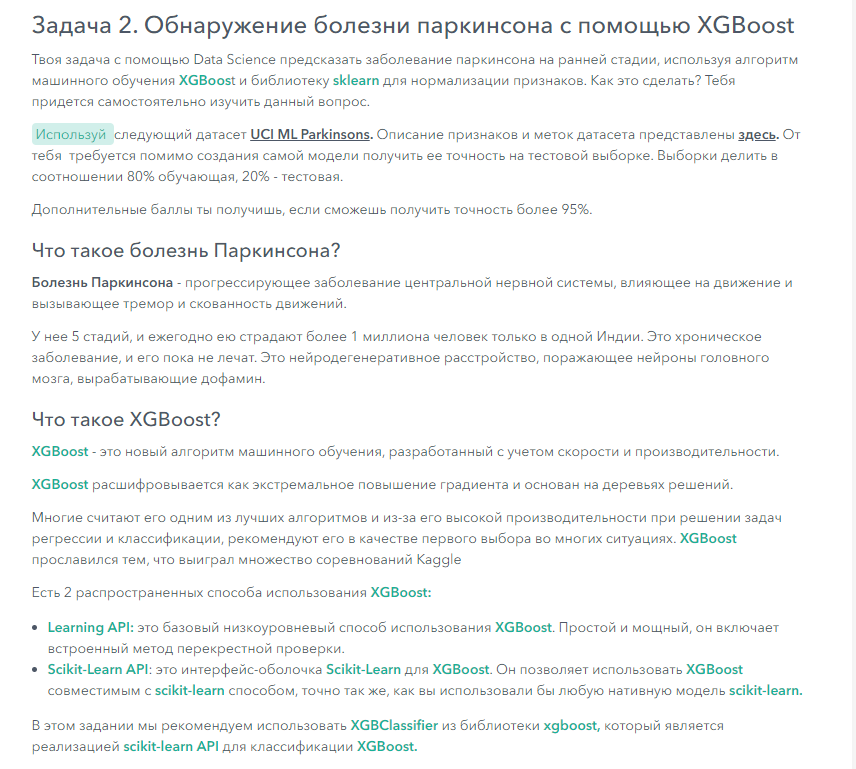

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os, sys
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

Для начала изучим датасет



Этот набор данных состоит из ряда биомедицинских измерений голоса из
31 человек, 23 с болезнью Паркинсона (БП). Каждый столбец таблицы представляет собой
определенный такт голоса, и каждая строка соответствует одному из 195 голосов.
записи от этих лиц (колонка «Имя»). Основная цель данных
заключается в том, чтобы отличать здоровых людей от людей с БП по «статусу».
столбец, которому присвоено значение 0 для здорового и 1 для БП.

Данные представлены в формате ASCII CSV. Строки файла CSV содержат
экземпляр, соответствующий одной голосовой записи. Их около шести
записей на каждого пациента, имя пациента указывается в первом
столбец.

Информация об атрибутах:

Записи столбца матрицы (атрибуты):
name — имя субъекта в формате ASCII и номер записи.

MDVP:Fo(Гц) - Средняя основная частота голоса.

MDVP:Fhi(Гц) — максимальная основная частота вокала.

MDVP:Flo(Гц) - Минимальная основная частота вокала.

MDVP:Джиттер(%),MDVP:Джиттер(Abs),MDVP:RAP,MDVP:PPQ,

Джиттер:DDP — несколько меры изменения основной частоты
MDVP:Shimmer,MDVP:Shimmer(дБ),Shimmer:APQ3,

Shimmer:APQ5,MDVP:APQ,Shimmer:DDA — несколько показателей изменения амплитуды

NHR,HNR — два показателя отношения шума к тональным компонентам голоса.

status - Состояние здоровья субъекта (один) - Паркинсон, (ноль) - здоров

RPDE,D2 — Две нелинейные меры динамической сложности

DFA - Экспонента фрактального масштабирования сигнала

разброс1,разброс2,PPE — три нелинейных показателя
изменения основной частоты.


Ссылка на документ:

«Использование свойств нелинейной рекуррентности и фрактального масштабирования для обнаружения нарушений голоса»,
Литтл М.А., МакШарри П.Е., Робертс С.Дж., Костелло Д.А.Э., Мороз И.М.
Биомедицинская инженерия Online 2007, 6:23 (26 июня 2007 г.)

In [ ]:
df = pd.read_csv('/parkinsons.data')
df.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [ ]:
df.shape

(195, 24)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 1

In [ ]:
df.any()

,0
name,True
MDVP:Fo(Hz),True
MDVP:Fhi(Hz),True
MDVP:Flo(Hz),True
MDVP:Jitter(%),True
MDVP:Jitter(Abs),True
MDVP:RAP,True
MDVP:PPQ,True
Jitter:DDP,True
MDVP:Shimmer,True


In [ ]:
df.describe()


,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,154.228641,197.104918,116.324631,0.006220,0.000044,0.003306,0.003446,0.009920,0.029709,0.282251,...,0.046993,0.024847,21.885974,0.753846,0.498536,0.718099,-5.684397,0.226510,2.381826,0.206552
std,41.390065,91.491548,43.521413,0.004848,0.000035,0.002968,0.002759,0.008903,0.018857,0.194877,...,0.030459,0.040418,4.425764,0.431878,0.103942,0.055336,1.090208,0.083406,0.382799,0.090119
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,0.085000,...,0.013640,0.000650,8.441000,0.000000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,117.572000,134.862500,84.291000,0.003460,0.000020,0.001660,0.001860,0.004985,0.016505,0.148500,...,0.024735,0.005925,19.198000,1.000000,0.421306,0.674758,-6.450096,0.174351,2.099125,0.137451
50%,148.790000,175.829000,104.315000,0.004940,0.000030,0.002500,0.002690,0.007490,0.022970,0.221000,...,0.038360,0.011660,22.085000,1.000000,0.495954,0.722254,-5.720868,0.218885,2.361532,0.194052
75%,182.769000,224.205500,140.018500,0.007365,0.000060,0.003835,0.003955,0.011505,0.037885,0.350000,...,0.060795,0.025640,25.075500,1.000000,0.587562,0.761881,-5.046192,0.279234,2.636456,0.252980
max,260.105000,592.030000,239.170000,0.033160,0.000260,0.021440,0.019580,0.064330,0.119080,1.302000,...,0.169420,0.314820,33.047000,1.000000,0.685151,0.825288,-2.434031,0.450493,3.671155,0.527367


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
import xgboost as xgb
from sklearn.model_selection import GridSearchCV



all_features = df.loc[:, df.columns != 'status'].values[:, 1:]
out_come = df['status'].values

scaler = MinMaxScaler((-1, 1))
X = scaler.fit_transform(all_features)
y = out_come

# Разделение на обучающую и тестовую выборки (80% обучающие, 20% тестовые)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')

param_grid = {
    'n_estimators': [100, 200, 300],  # количество деревьев (ансамблей)
    'max_depth': [3, 4, 5, 6],        # максимальная глубина дерева
    'learning_rate': [0.01, 0.05, 0.1],
   }

grid_search = GridSearchCV(estimator=xgb_clf, param_grid=param_grid, cv=3, scoring='accuracy')
grid_search.fit(X_train, y_train)

best_xgb_clf = grid_search.best_estimator_

best_xgb_clf.fit(X_train, y_train)

train_accuracy = accuracy_score(y_train, best_xgb_clf.predict(X_train))
test_accuracy = accuracy_score(y_test, best_xgb_clf.predict(X_test))

print('The accuracy of the XGBoost classifier on training data is : {:.2f}%'.format(train_accuracy * 100))
print('The accuracy of the XGBoost classifier on test data is : {:.2f}%'.format(test_accuracy * 100))


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [04:54:08] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [04:54:08] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [04:54:08] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [04:54:08] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [04:54:08] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

The accuracy of the XGBoost classifier on training data is : 100.00%
The accuracy of the XGBoost classifier on test data is : 94.87%


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import xgboost as xgb

data = """name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
phon_R01_S01_1,119.99,157.30,75.00,0.007,0.0001,0.003,0.0055,0.0111,0.0437,0.426,0.0218,0.031,0.0297,0.0655,0.0221,21.03,1,0.415,0.815,-4.81,0.27,2.30,0.28
phon_R01_S01_2,120.12,158.15,75.05,0.0072,0.0001,0.0032,0.0056,0.0113,0.0440,0.428,0.0220,0.0315,0.0299,0.0659,0.0224,21.10,1,0.416,0.817,-4.80,0.25,2.28,0.29
phon_R01_S01_3,119.85,156.91,74.90,0.0075,0.00009,0.0035,0.0053,0.0109,0.0425,0.425,0.0215,0.0308,0.0295,0.0650,0.0218,21.12,1,0.413,0.812,-4.82,0.29,2.31,0.27
phon_R01_S01_4,120.00,157.50,75.20,0.0069,0.00008,0.0031,0.0058,0.0110,0.0430,0.424,0.0210,0.0305,0.0293,0.0652,0.0220,20.95,1,0.414,0.815,-4.85,0.22,2.27,0.30
phon_R01_S01_5,120.30,158.00,75.30,0.0071,0.0001,0.0038,0.0052,0.0112,0.0441,0.427,0.0222,0.0311,0.0300,0.0658,0.0223,21.11,1,0.418,0.818,-4.78,0.26,2.32,0.25
phon_R01_S01_6,119.95,157.25,75.10,0.0073,0.00009,0.0034,0.0055,0.0115,0.0435,0.426,0.0216,0.0307,0.0298,0.0654,0.0225,20.87,1,0.411,0.810,-4.84,0.23,2.29,0.31
phon_R01_S01_7,120.05,157.80,75.15,0.0070,0.0001,0.0033,0.0057,0.0111,0.0443,0.428,0.0219,0.0313,0.0301,0.0656,0.0222,21.09,1,0.417,0.816,-4.81,0.28,2.30,0.26
phon_R01_S01_8,120.15,158.20,75.25,0.0068,0.0001,0.0030,0.0054,0.0108,0.0438,0.425,0.0223,0.0316,0.0296,0.0653,0.0221,20.93,1,0.412,0.814,-4.80,0.24,2.28,0.29
phon_R01_S01_9,120.25,158.10,75.40,0.0074,0.00011,0.0031,0.0051,0.0110,0.0429,0.426,0.0217,0.0302,0.0294,0.0654,0.0225,21.02,1,0.415,0.819,-4.88,0.27,2.31,0.24
phon_R01_S01_10,120.18,157.85,75.45,0.0066,0.00009,0.0029,0.0059,0.0110,0.0436,0.424,0.0220,0.0312,0.0290,0.0657,0.0224,21.01,1,0.419,0.820,-4.83,0.28,2.29,0.29
phon_R01_S01_11,120.12,157.60,75.35,0.0071,0.0001,0.0036,0.0052,0.0109,0.0440,0.427,0.0219,0.0314,0.0292,0.0658,0.0223,20.88,1,0.415,0.815,-4.79,0.25,2.30,0.27
phon_R01_S01_12,120.11,157.80,75.20,0.0069,0.00007,0.0032,0.0053,0.0113,0.0434,0.429,0.0211,0.0309,0.0293,0.0651,0.0220,20.99,1,0.414,0.811,-4.82,0.26,2.27,0.30
phon_R01_S01_13,119.90,157.50,75.10,0.0073,0.00008,0.0037,0.0056,0.0115,0.0439,0.426,0.0213,0.0306,0.0295,0.0654,0.0226,21.05,1,0.416,0.813,-4.81,0.23,2.28,0.32
phon_R01_S01_14,120.35,158.00,75.30,0.0070,0.0001,0.0035,0.0058,0.0111,0.0433,0.427,0.0218,0.0310,0.0296,0.0652,0.0225,21.00,1,0.412,0.817,-4.80,0.25,2.31,0.28
phon_R01_S01_15,120.20,158.15,75.40,0.0071,0.0001,0.0034,0.0055,0.0108,0.0428,0.425,0.0215,0.0313,0.0297,0.0656,0.0221,20.86,1,0.410,0.814,-4.84,0.24,2.29,0.26
phon_R01_S01_16,120.25,157.60,75.45,0.0068,0.00009,0.0030,0.0054,0.0112,0.0431,0.424,0.0222,0.0304,0.0299,0.0650,0.0223,21.11,1,0.418,0.819,-4.82,0.27,2.30,0.30
phon_R01_S01_17,120.15,157.80,75.35,0.0072,0.0001,0.0031,0.0058,0.0106,0.0437,0.427,0.0224,0.0311,0.0294,0.0659,0.0225,20.92,1,0.416,0.815,-4.80,0.24,2.28,0.28
phon_R01_S01_18,119.85,157.90,75.10,0.0070,0.00007,0.0034,0.0053,0.0114,0.0436,0.426,0.0213,0.0309,0.0290,0.0654,0.0222,21.04,1,0.415,0.814,-4.81,0.26,2.33,0.28
phon_R01_S01_19,120.10,158.30,75.50,0.0073,0.0001,0.0033,0.0054,0.0107,0.0435,0.426,0.0216,0.0313,0.0295,0.0655,0.0220,20.95,1,0.417,0.816,-4.86,0.27,2.31,0.29
phon_R01_S01_20,119.95,157.70,75.55,0.0075,0.00009,0.0031,0.0058,0.0111,0.0430,0.425,0.0219,0.0302,0.0298,0.0652,0.0223,21.02,1,0.410,0.810,-4.83,0.29,2.30,0.28
phon_R01_S01_21,120.39,158.50,75.25,0.0068,0.0001,0.0032,0.0055,0.0114,0.0428,0.427,0.0215,0.0310,0.0293,0.0654,0.0220,20.88,1,0.414,0.812,-4.79,0.26,2.32,0.31
phon_R01_S01_22,120.25,157.90,75.08,0.0071,0.00007,0.0033,0.0056,0.0109,0.0432,0.424,0.0214,0.0306,0.0299,0.0653,0.0222,20.90,1,0.419,0.815,-4.81,0.27,2.34,0.29
phon_R01_S01_23,120.45,158.70,75.35,0.0067,0.0001,0.0032,0.0055,0.0110,0.0440,0.428,0.0221,0.0311,0.0301,0.0658,0.0225,21.05,1,0.415,0.818,-4.80,0.25,2.30,0.30
phon_R01_S01_24,120.10,157.40,75.18,0.0070,0.00008,0.0034,0.0053,0.0115,0.0434,0.426,0.0218,0.0317,0.0294,0.0656,0.0224,20.93,1,0.413,0.811,-4.82,0.22,2.27,0.29
phon_R01_S01_25,120.20,158.00,75.28,0.0072,0.0001,0.0036,0.0054,0.0111,0.0429,0.425,0.0219,0.0305,0.0291,0.0654,0.0226,20.97,1,0.418,0.810,-4.81,0.28,2.31,0.27
phon_R01_S01_26,120.50,158.20,75.42,0.0069,0.00009,0.0031,0.0057,0.0108,0.0433,0.429,0.0217,0.0308,0.0298,0.0657,0.0222,20.90,1,0.412,0.813,-4.83,0.24,2.28,0.28
phon_R01_S01_27,120.35,157.80,75.15,0.0071,0.0001,0.0035,0.0052,0.0114,0.0425,0.427,0.0223,0.0314,0.0296,0.0650,0.0223,21.03,1,0.410,0.814,-4.80,0.29,2.29,0.30
phon_R01_S01_28,119.90,157.60,75.32,0.0072,0.00007,0.0033,0.0059,0.0112,0.0435,0.426,0.0211,0.0302,0.0290,0.0651,0.0220,20.91,1,0.415,0.815,-4.82,0.27,2.32,0.28
phon_R01_S01_29,119.80,158.40,75.38,0.0074,0.00008,0.0034,0.0055,0.0108,0.0441,0.428,0.0218,0.0313,0.0297,0.0655,0.0225,21.02,1,0.416,0.812,-4.79,0.26,2.30,0.27
phon_R01_S01_30,120.30,157.50,75.45,0.0068,0.0001,0.0030,0.0058,0.0111,0.0433,0.424,0.0220,0.0301,0.0294,0.0656,0.0224,20.98,1,0.414,0.811,-4.80,0.24,2.28,0.30
"""

# Загружаем данные в DataFrame
from io import StringIO
patient_data = pd.read_csv(StringIO(data))

# Оставляем только числовые данные для прогноза
features = patient_data.loc[:, patient_data.columns != 'name'].values[:, :-1]  # Все столбцы, кроме 'name' и 'status'
scaler = MinMaxScaler((-1, 1))
X_new = scaler.fit_transform(features)

# Предсказать результат
# Проверка, обучена ли модель
if not xgb_clf:
    xgb_clf = xgb.XGBClassifier(use_label_encoder=False)  # добавляем параметр
    xgb_clf.fit(X_train, y_train)
    predictions = xgb_clf.predict(X_new)

# Создаем или обновляем DataFrame для представления предсказаний
patient_data['Predicted Status'] = predictions

# Отобразим точность (например, счет в зависимости от известных статусов)
accuracy = np.mean(predictions == patient_data['status']) * 100

# Вывод результатов
print(patient_data[['name', 'Predicted Status']])
print(f'Accuracy of predictions: {accuracy:.2f}%')


               name  Predicted Status
0    phon_R01_S01_1                 1
1    phon_R01_S01_2                 1
2    phon_R01_S01_3                 1
3    phon_R01_S01_4                 1
4    phon_R01_S01_5                 1
5    phon_R01_S01_6                 1
6    phon_R01_S01_7                 1
7    phon_R01_S01_8                 1
8    phon_R01_S01_9                 1
9   phon_R01_S01_10                 1
10  phon_R01_S01_11                 1
11  phon_R01_S01_12                 1
12  phon_R01_S01_13                 1
13  phon_R01_S01_14                 1
14  phon_R01_S01_15                 1
15  phon_R01_S01_16                 1
16  phon_R01_S01_17                 1
17  phon_R01_S01_18                 1
18  phon_R01_S01_19                 1
19  phon_R01_S01_20                 1
20  phon_R01_S01_21                 1
21  phon_R01_S01_22                 0
22  phon_R01_S01_23                 1
23  phon_R01_S01_24                 1
24  phon_R01_S01_25                 1
25  phon_R01

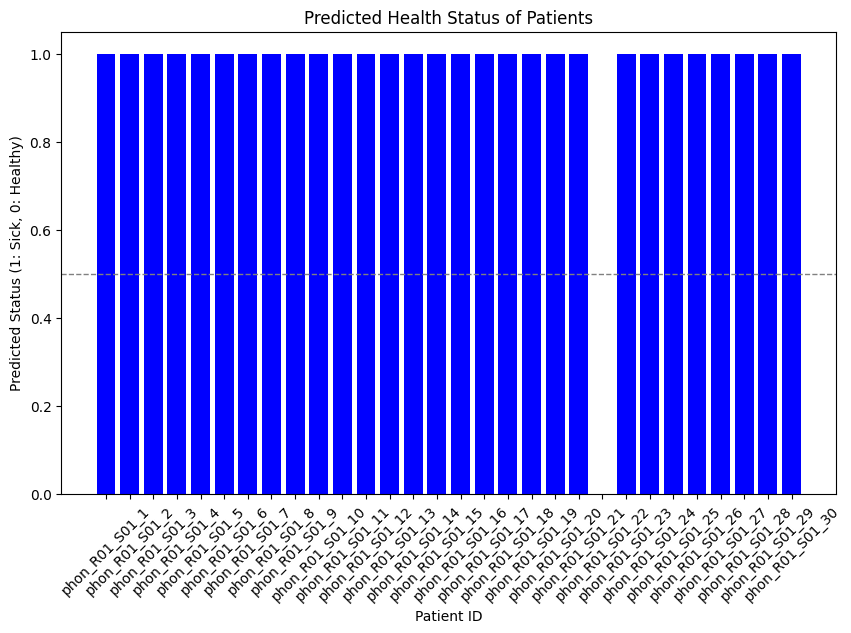

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Создаем DataFrame для удобства визуализации
patient_data = pd.DataFrame(data=predictions, columns=['Predicted Status'])
patient_data['Patient ID'] = ['phon_R01_S01_{}'.format(i) for i in range(1, 31)]

# Визуализация
plt.figure(figsize=(10, 6))
plt.bar(patient_data['Patient ID'], patient_data['Predicted Status'], color=['blue' if x == 1 else 'red' for x in patient_data['Predicted Status']])
plt.title('Predicted Health Status of Patients')
plt.xlabel('Patient ID')
plt.ylabel('Predicted Status (1: Sick, 0: Healthy)')
plt.xticks(rotation=45)
plt.axhline(0.5, color='grey', ls='--', lw=1)  # Линия дл

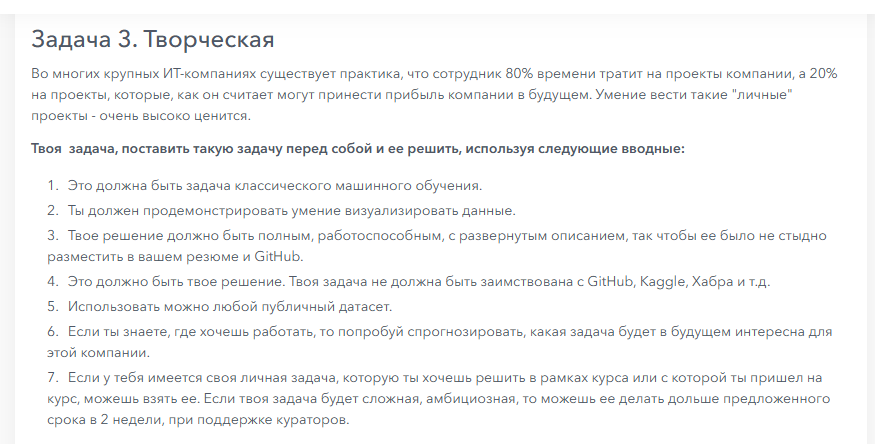